The aim of this notebook is to compare NBr60 against 52. In 54 qrun is much smaller for no apparent reason.

For this reason, I'll compare the MSW input files for both runs.

The comparrison outcome is recorded in ./compare_Ins-NBr60_Vs_NBr52.xlsx

In [1]:
import pandas as pd
from WS_Mdl.core import *
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Options

In [136]:
M = Mdl_N('NBr67')
MB = Mdl_N('NBr59')

In [137]:
Aa = M.Mdl_area - M.N_R*2*M.cellsize - (M.N_C-2)*2*M.cellsize
Aa

103158900.0

# 2. Explore MSW In files

Procedure works as follows:
1. Check if DFs for Fis are identical (.equals) (Status=3)
2. If not, check if they're almost identical (Status=2) or mostly similar (Status=1), or problematic (Status=0)

## 2.0 idf_svat
Starting with this one cause it'll tell help us find the extra SVATs in NBr54, which will be useful for the other 

### Load & Clean

In [4]:
for k in M.MSW_In.d.keys():
    print(k)
    for i in M.MSW_In.d[k].columns:
        if 'wet' in i:
            print(f"\t{i}")

 1 - area_svat.inp 🟢
 2 - fact_svat.inp 🟢
 3 - idf_svat.inp 🟢
 4 - infi_svat.inp 🟢
 5 - init_svat.inp 🟢
 6 - luse_svat.inp 🟢
 7 - mete_grid.inp 🟢
 8 - mod2svat.inp 🟢
 9 - para_sim.inp 🟢
10 - scap_svat.inp 🟢
11 - sel_key_svat_per.inp 🟢
12 - svat2etrefgrid.inp 🟢
13 - svat2precgrid.inp 🟢
14 - svat2swnr_roff.inp 🟢
15 - time_sim.inp 🟡 - Missing 2 columns
16 - tiop_sim.inp 🟢
area_svat
fact_svat
idf_svat
infi_svat
init_svat
luse_svat
	crop resistance, wet leaves in PM
mete_grid
mod2svat
para_sim
scap_svat
sel_key_svat_per
svat2etrefgrid
svat2precgrid
svat2swnr_roff
time_sim
tiop_sim


In [5]:
Fi = 'idf_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

 1 - area_svat.inp 🟢
 2 - fact_svat.inp 🟢
 3 - idf_svat.inp 🟢
 4 - infi_svat.inp 🟢
 5 - init_svat.inp 🟢
 6 - luse_svat.inp 🟢
 7 - mete_grid.inp 🟢
 8 - mod2svat.inp 🟢
 9 - para_sim.inp 🟢
10 - scap_svat.inp 🟢
11 - sel_key_svat_per.inp 🟢
12 - sel_svat_bda.inp 🔴 'sel_svat_bda.inp'
13 - svat2etrefgrid.inp 🟢
14 - svat2precgrid.inp 🟢
15 - svat2swnr_roff.inp 🟢
16 - time_sim.inp 🟡 - Missing 2 columns
17 - tiop_sim.inp 🟢
18 - uscl_svat.inp 🟢


False

In [6]:
DF.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)
DF_B.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)

### Inspect

In [7]:
DF.describe()

,SVAT,R,C,X,Y
count,184024.000000,184024.000000,184024.000000,184024.000000,184024.00000
mean,92012.500000,168.473878,245.539783,119225.994571,392000.65304
std,53123.297306,100.363154,139.939980,3498.499490,2509.07884
min,1.000000,2.000000,2.000000,113137.500000,387637.50000
25%,46006.750000,78.000000,124.000000,116187.500000,389787.50000
50%,92012.500000,169.000000,247.000000,119262.500000,391987.50000
75%,138018.250000,257.000000,369.000000,122312.500000,394262.50000
max,184024.000000,343.000000,479.000000,125062.500000,396162.50000


In [8]:
DF_B.describe()

,SVAT,R,C,X,Y
count,183388.00000,183388.000000,183388.000000,183388.000000,183388.000000
mean,91694.50000,168.676287,245.710188,119230.298466,391995.593087
std,52939.69992,100.378936,139.833887,3495.872738,2509.473601
min,1.00000,2.000000,2.000000,113137.500000,387637.500000
25%,45847.75000,78.000000,124.000000,116187.500000,389787.500000
50%,91694.50000,169.000000,247.000000,119262.500000,391987.500000
75%,137541.25000,257.000000,369.000000,122312.500000,394262.500000
max,183388.00000,343.000000,479.000000,125062.500000,396162.500000


Seems like imod_python creates SVATs in a different way than imod5, as even though we've now removed the outer rows and columns, there are still more SVATs in NBr60 than in NBr52. Let's explore this further.

### investigate SVAT Diffs

There are 165120 (N_R*N_C) cells in the model. There are more SVATs than that though (even though the first and last row and column are inactive in iMOD5). That is because cells with urban_area>0 get 2 SVATs (I checked in QGIS).

In [9]:
DF['R_C'] = DF['R'].astype(str) + '_' + DF['C'].astype(str)
DF_B['R_C'] = DF_B['R'].astype(str) + '_' + DF_B['C'].astype(str)

In [10]:
print(f"{len(DF)-len(DF_B)} SVAT grid cells in NBr54 that are not in NBr52 - {(len(DF)-len(DF_B))/len(DF)*100:.2f}%")

636 SVAT grid cells in NBr54 that are not in NBr52 - 0.35%


I explore this later

In [11]:
DF.loc[DF['R_C'].isin(DF_B['R_C']) == False]

,SVAT,R,C,X,Y,R_C
105399,105400,222,241,119112.5,390662.5,222_241


This is the only R_C that's completely missing from B. It is fully wetted (625m2 wetted area), so it might make sense imod5 removed it. 

### Plot DSs to explore SVAT creation in NBr60 vs NBr52

In [12]:
DS = M.MSW_In.DS
DS_B = MB.MSW_In.DS

 1 - area_svat 🟢
 2 - fact_svat 🔴 "None of ['SVAT'] are in the columns"
 3 - infi_svat 🟢
 4 - init_svat 🔴 "None of ['SVAT'] are in the columns"
 5 - luse_svat 🔴 "None of ['SVAT'] are in the columns"
 6 - mete_grid 🔴 "None of ['SVAT'] are in the columns"
 7 - mod2svat 🔴 "None of ['SVAT'] are in the columns"
 8 - para_sim 🔴 "None of ['SVAT'] are in the columns"
 9 - scap_svat 🟢
10 - sel_key_svat_per 🔴 "None of ['SVAT'] are in the columns"
11 - svat2etrefgrid 🟢
12 - svat2precgrid 🟢
13 - svat2swnr_roff 🟢
14 - time_sim 🔴 "None of ['SVAT'] are in the columns"
15 - tiop_sim 🔴 "None of ['SVAT'] are in the columns"
 1 - area_svat 🟢
 2 - fact_svat 🔴 "None of ['SVAT'] are in the columns"
 3 - infi_svat 🟢
 4 - init_svat 🔴 "None of ['SVAT'] are in the columns"
 5 - luse_svat 🔴 "None of ['SVAT'] are in the columns"
 6 - mete_grid 🔴 "None of ['SVAT'] are in the columns"
 7 - mod2svat 🔴 "None of ['SVAT'] are in the columns"
 8 - para_sim 🔴 "None of ['SVAT'] are in the columns"
 9 - scap_svat 🟢
10 - se

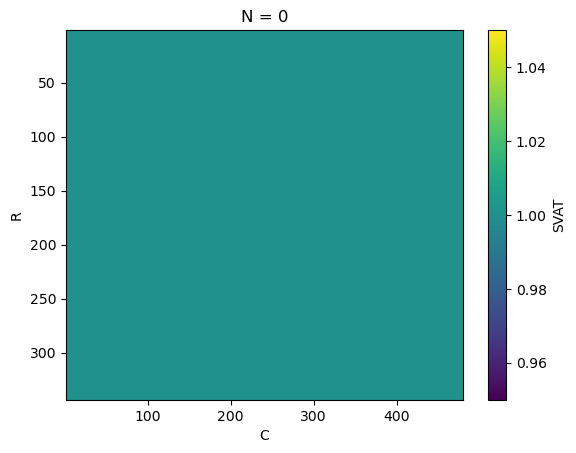

In [13]:
DS['SVAT'].sel(N=0).notnull().plot(yincrease=False)

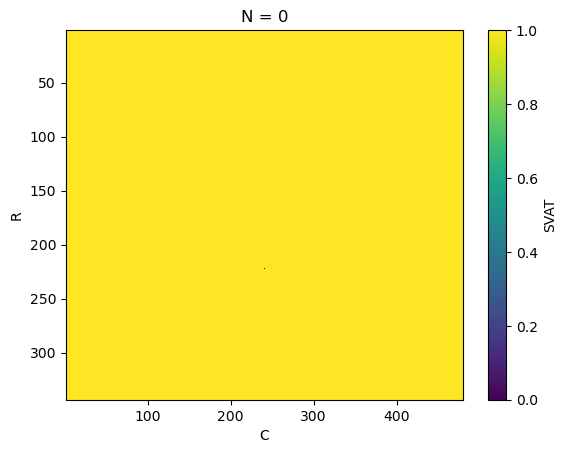

In [14]:
DS_B['SVAT'].sel(N=0).notnull().plot(yincrease=False)

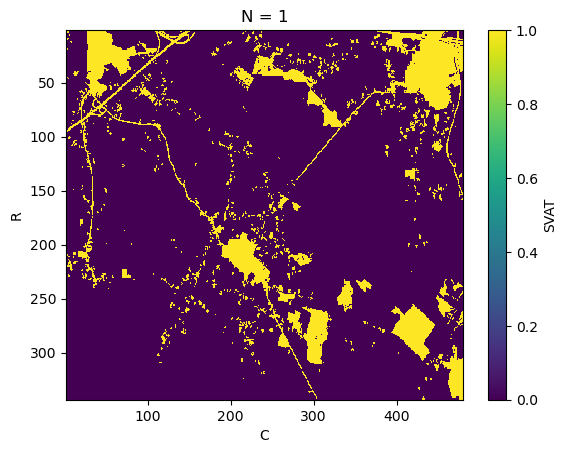

In [15]:
DS['SVAT'].sel(N=1).notnull().plot(yincrease=False)

In [16]:
M.MdlN, MB.MdlN

('NBr66', 'NBr59')

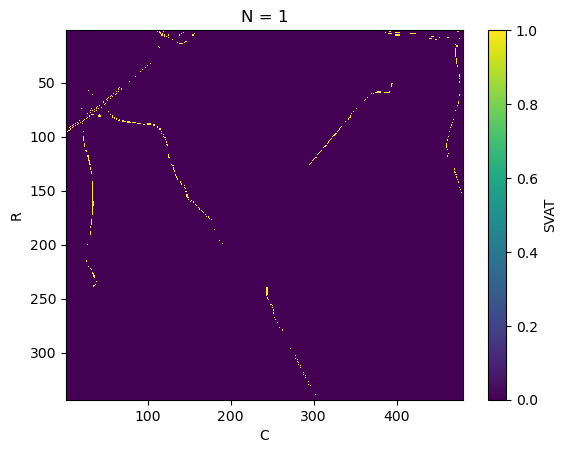

In [17]:
extra = DS['SVAT'].sel(N=1).notnull() & DS_B['SVAT'].sel(N=1).isnull() # Extra SVATs in NBr60 that are not in NBr52
extra.plot(yincrease=False)

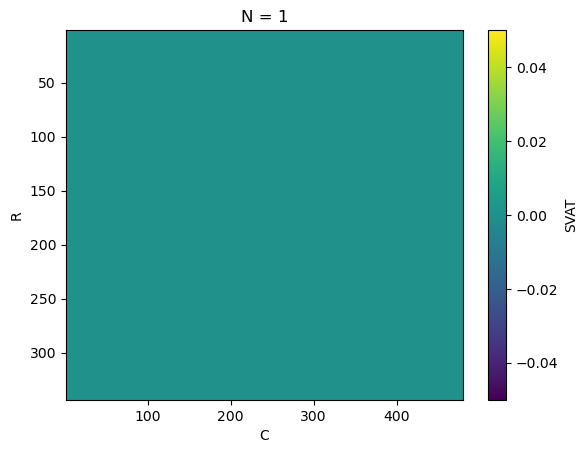

In [18]:
extra = DS['SVAT'].sel(N=1).isnull() & DS_B['SVAT'].sel(N=1).notnull() # Extra SVATs in NBr60 that are not in NBr52
extra.plot(yincrease=False)

In [19]:
extra.sum()

<xarray.DataArray 'SVAT' ()> Size: 8B
array(0)
Coordinates:
    N        int64 8B 1

#### Explore smaller area, to understand what's happening

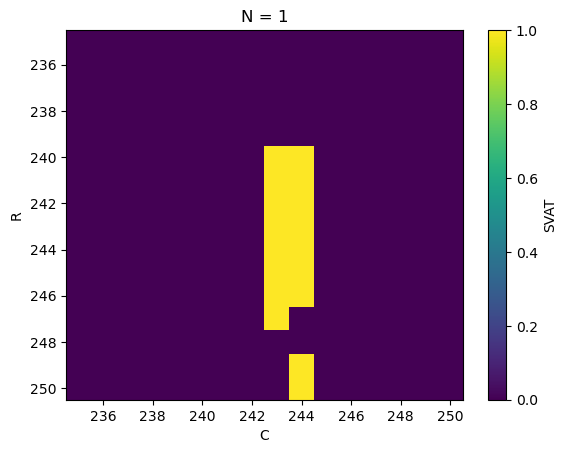

In [20]:
extra = DS['SVAT'].sel(N=1).notnull() & DS_B['SVAT'].sel(N=1).isnull() # Extra SVATs in NBr60 that are not in NBr52
(extra.sel(R=slice(235, 250), C=slice(235, 250))).plot(yincrease=False)

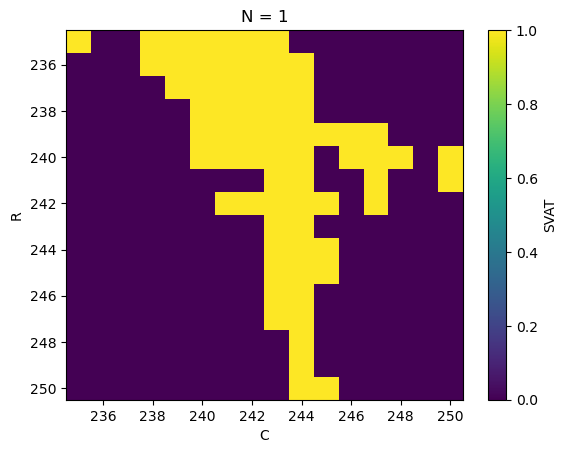

In [21]:
DS['SVAT'].sel(N=1).notnull().sel(R=slice(235, 250), C=slice(235, 250)).plot(yincrease=False)

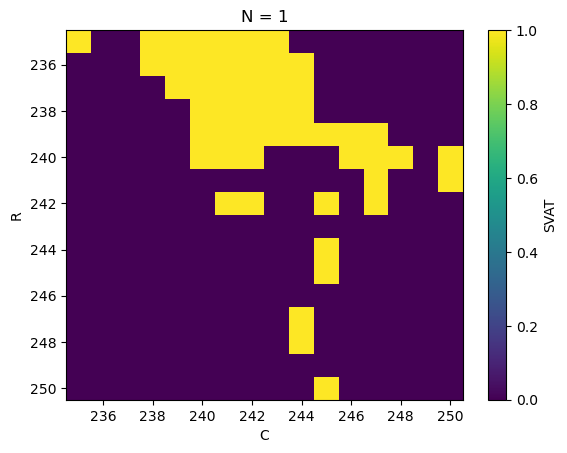

In [22]:
DS_B['SVAT'].sel(N=1).notnull().sel(R=slice(235, 250), C=slice(235, 250)).plot(yincrease=False)

- imod_python (NBr60) creates a 2nd SVAT for the same cell when urban area > 0.
- imod5 (NBr52) creates a 2nd SVAT when urban area > 0 and wetted area <= 20% (not sure about the exact percentage, but I see cells with 75 (or 86.1192) m2 wetted area getting a 2nd SVAT, while cells with 125m2 don't (in both cases urban area > 0)). (total cell area is 625m2)

## 2.1 area_svat

### Compare DFs

In [23]:
Fi = 'area_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [24]:
DF.describe()

,SVAT,area,soil surface elevation,temperature at bottom of soil profile,soil physical unit number,soil physical unit descriptive string,land use type,root zone thickness / maximum,meteorological region code number,local calibration factor for precipitation,local calibration factor for potential evapotranspiration of reference crop
count,184024.000000,184024.000000,184024.000000,0.0,184024.000000,0.0,184024.000000,184024.000000,0.0,0.0,0.0
mean,92012.500000,534.956726,12.867458,NaN,105.784756,NaN,8.750413,0.517066,NaN,NaN,NaN
std,53123.297306,153.569300,5.253307,NaN,34.970745,NaN,7.183651,0.299450,NaN,NaN,NaN
min,1.000000,1.110000,1.084000,NaN,36.000000,NaN,1.000000,0.050000,NaN,NaN,NaN
25%,46006.750000,500.000000,8.853000,NaN,79.000000,NaN,1.000000,0.300000,NaN,NaN,NaN
50%,92012.500000,625.000000,12.354000,NaN,84.000000,NaN,11.000000,0.350000,NaN,NaN,NaN
75%,138018.250000,625.000000,16.640000,NaN,130.000000,NaN,17.000000,1.000000,NaN,NaN,NaN
max,184024.000000,625.000000,29.856000,NaN,360.000000,NaN,22.000000,1.000000,NaN,NaN,NaN


In [25]:
DF_B.describe()

,SVAT,area,soil surface elevation,temperature at bottom of soil profile,soil physical unit number,soil physical unit descriptive string,land use type,root zone thickness / maximum,meteorological region code number,local calibration factor for precipitation,local calibration factor for potential evapotranspiration of reference crop
count,183388.00000,183388.000000,183388.000000,0.0,183388.000000,0.0,183388.000000,183388.000000,183388.0,183388.0,183388.0
mean,91694.50000,536.798038,12.879104,NaN,105.777096,NaN,8.718346,0.481972,1.0,1.0,1.0
std,52939.69992,150.606197,5.252083,NaN,34.991614,NaN,7.175392,0.317850,0.0,0.0,0.0
min,1.00000,1.110000,1.084000,NaN,36.000000,NaN,1.000000,0.100000,1.0,1.0,1.0
25%,45847.75000,500.000000,8.867000,NaN,79.000000,NaN,1.000000,0.300000,1.0,1.0,1.0
50%,91694.50000,625.000000,12.360500,NaN,84.000000,NaN,11.000000,0.350000,1.0,1.0,1.0
75%,137541.25000,625.000000,16.655000,NaN,130.000000,NaN,17.000000,0.750000,1.0,1.0,1.0
max,183388.00000,625.000000,29.856000,NaN,360.000000,NaN,22.000000,1.000000,1.0,1.0,1.0


In [26]:
f"{(DF['area'].sum() - DF_B['area'].sum() ) / DF_B['area'].sum() *100:.2f}%"

'0.00%'

We have 3.8% difference in precipitation between runs, exactly the same as the area difference.

Let's attach this Fieter to the DS and explore spatially.

### Compare DS Fis

#### area

Let's compare the area per R and C.

In [27]:
param = 'area'

In [28]:
area_RC = DS[param].sum(dim='N') #, skipna=True)
area_RC_B = DS_B[param].sum(dim='N') #, skipna=True)
area_RC_Diff = area_RC - area_RC_B

##### Extra plots

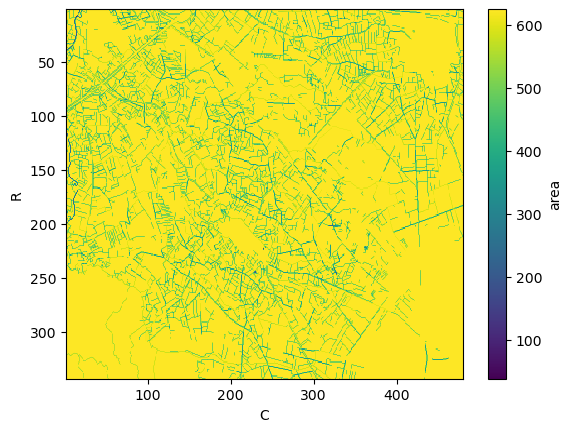

In [29]:
area_RC.plot(yincrease=False)

In [30]:
area_RC.min()

<xarray.DataArray 'area' ()> Size: 8B
array(38.25)

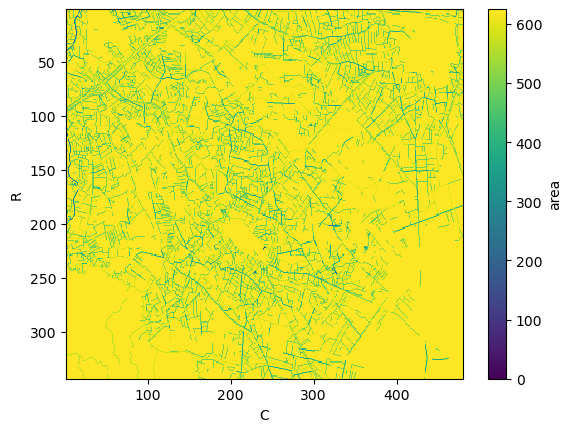

In [31]:
area_RC_B.plot(yincrease=False)

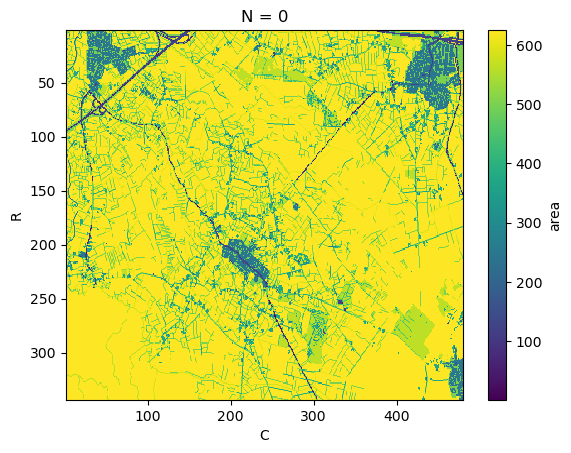

In [32]:
DS[param].sel(N=0).plot(yincrease=False)

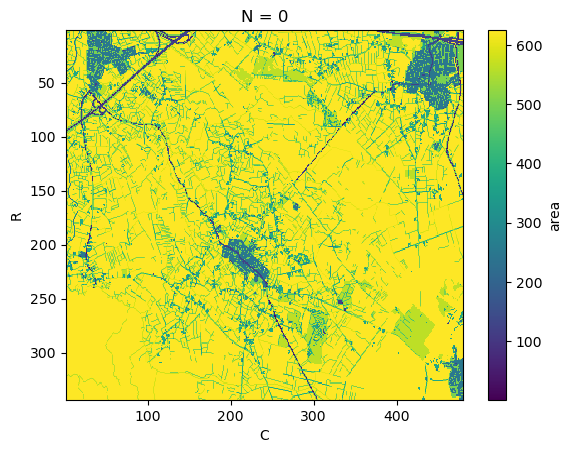

In [33]:
DS_B[param].sel(N=0).plot(yincrease=False)

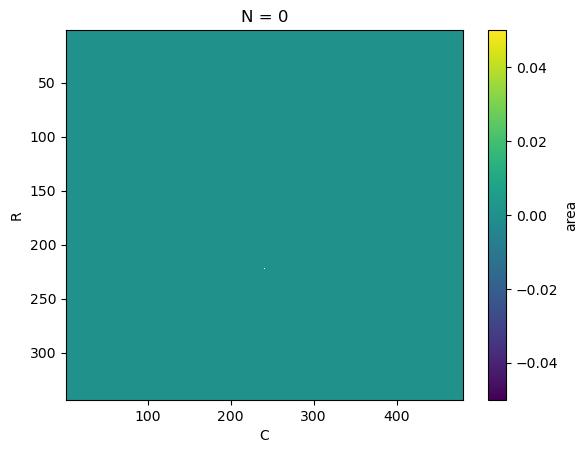

In [34]:
(DS[param].sel(N=0) - DS_B[param].sel(N=0)).plot(yincrease=False)

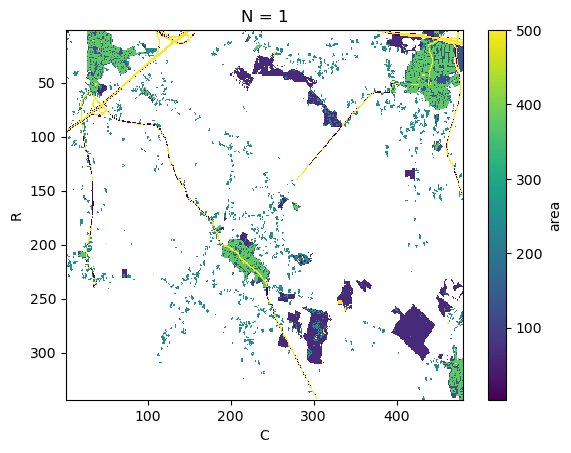

In [35]:
DS[param].sel(N=1).plot(yincrease=False)

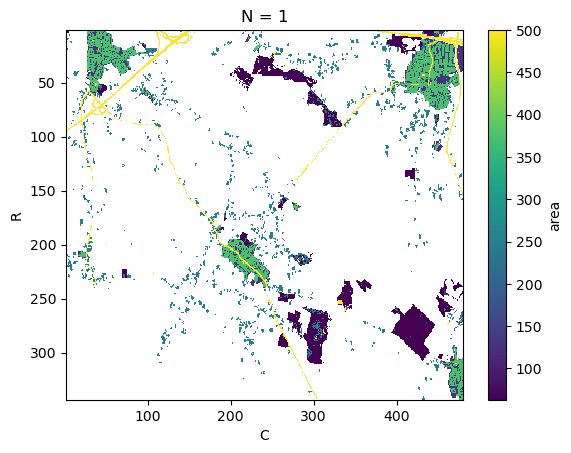

In [36]:
DS_B[param].sel(N=1).plot(yincrease=False)

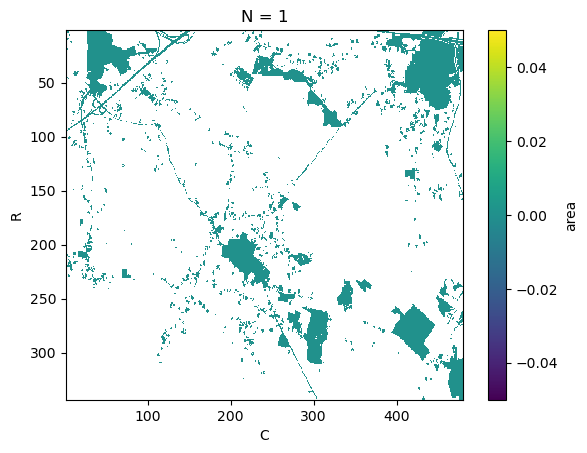

In [37]:
(DS[param].sel(N=1) - DS_B[param].sel(N=1)).plot(yincrease=False)

##### Main plots

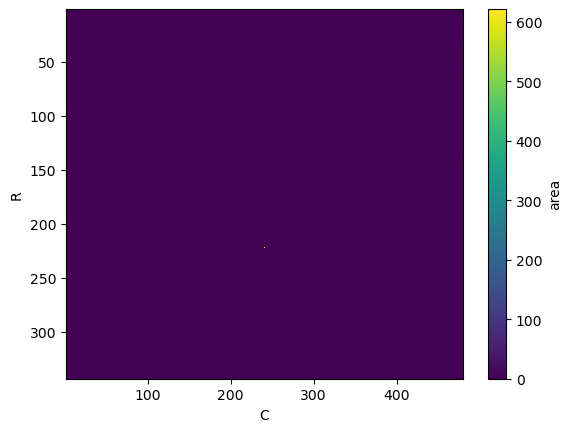

In [38]:
area_RC_Diff.plot(yincrease=False)

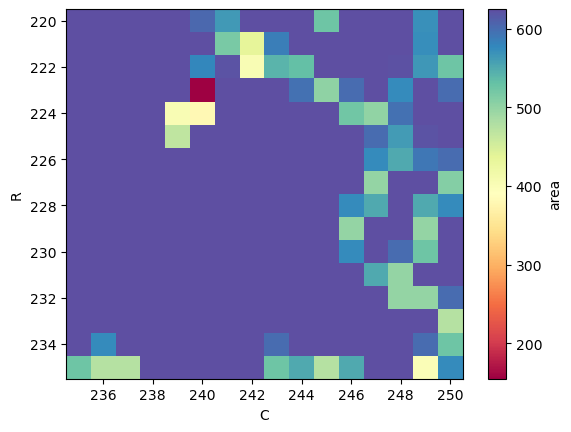

In [39]:
area_RC.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

In [40]:
area_RC.sel(R=slice(220, 235), C=slice(235, 250)).min()

<xarray.DataArray 'area' ()> Size: 8B
array(155.05)

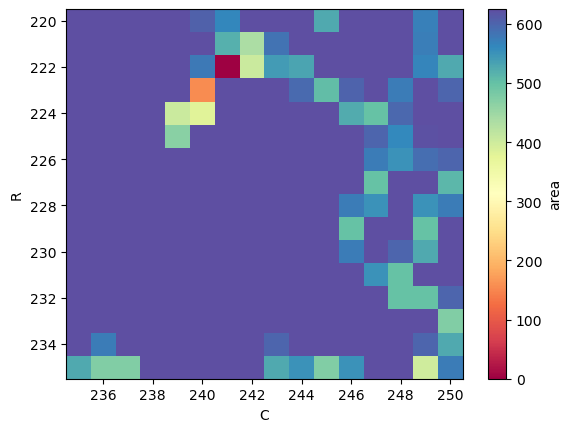

In [41]:
area_RC_B.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

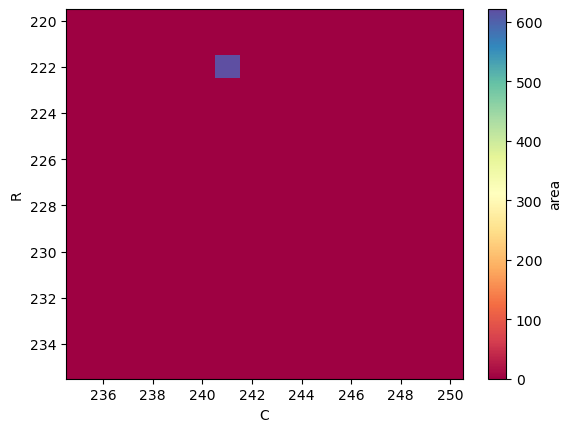

In [42]:
area_RC_Diff.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

It's clear that imod5 removes wetted area from the total cell area. It's not as clear what imod_python does, but there is a big difference in wetted cell areas.

In [43]:
DF.keys()

Index(['SVAT', 'area', 'soil surface elevation',
       'temperature at bottom of soil profile', 'soil physical unit number',
       'soil physical unit descriptive string', 'land use type',
       'root zone thickness / maximum', 'meteorological region code number',
       'local calibration factor for precipitation',
       'local calibration factor for potential evapotranspiration of reference crop'],
      dtype='object')

#### temperature at bottom of soil profile

In [44]:
param = DF_B.columns[2]
param

'soil surface elevation'

In [45]:
area_RC = DS[param].sum(dim='N', skipna=True)
area_RC_B = DS_B[param].sum(dim='N', skipna=True)
area_RC_Diff = area_RC - area_RC_B

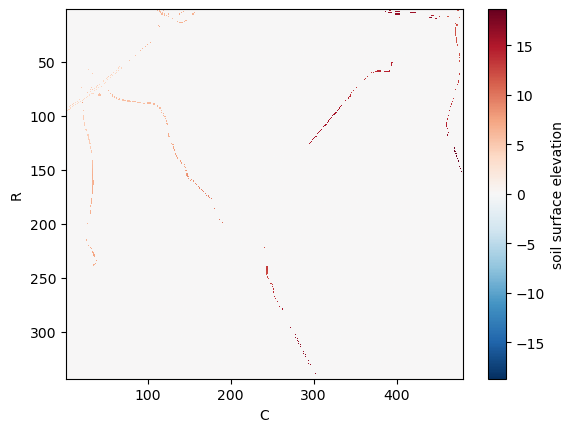

In [46]:
area_RC_Diff.plot(yincrease=False)

This is the same pattern as extra SVATs.

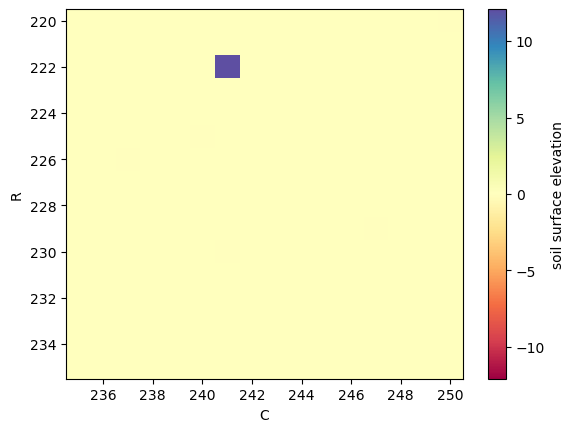

In [47]:
area_RC_Diff.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

#### Other parameters

temperature at bottom of soil profile


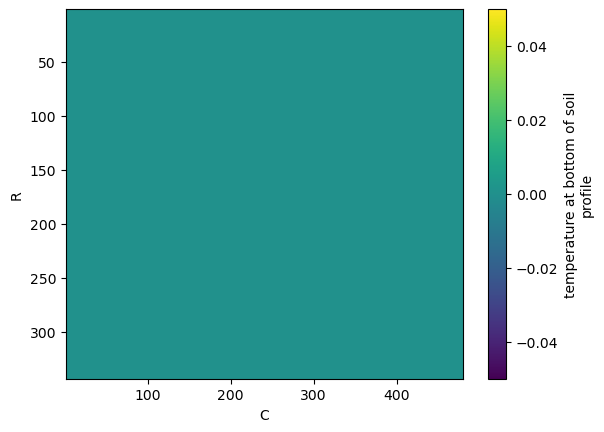

soil physical unit number


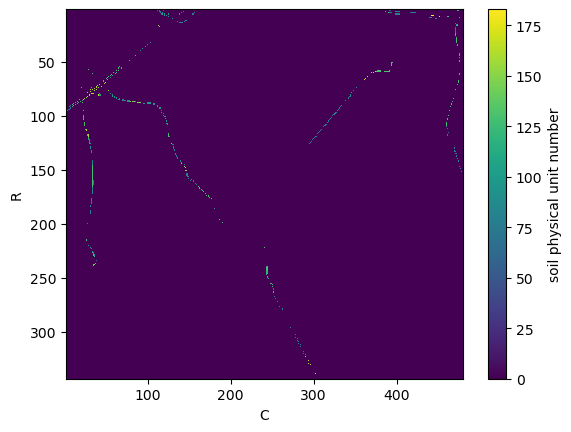

soil physical unit descriptive string


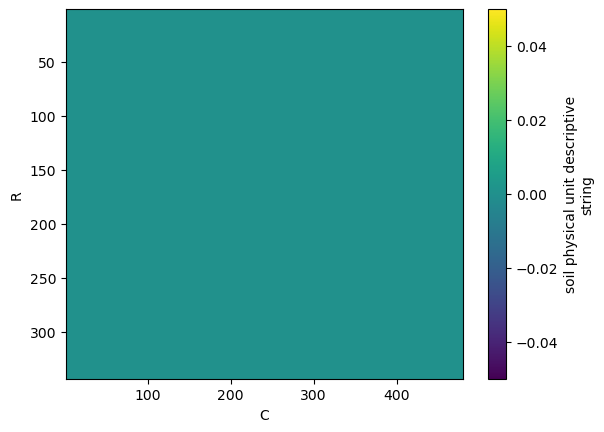

land use type


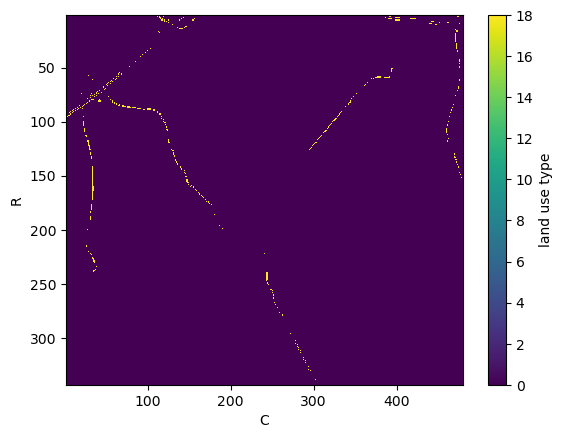

root zone thickness / maximum


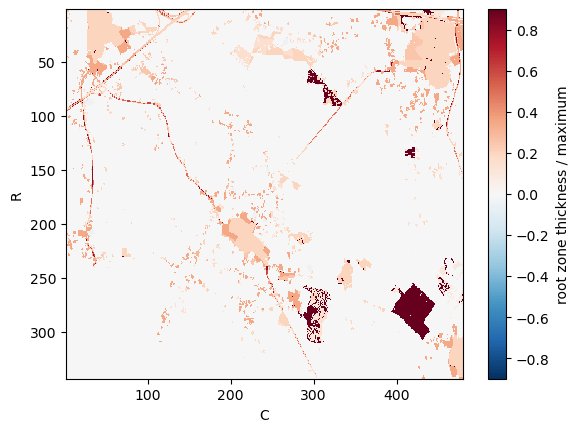

meteorological region code number


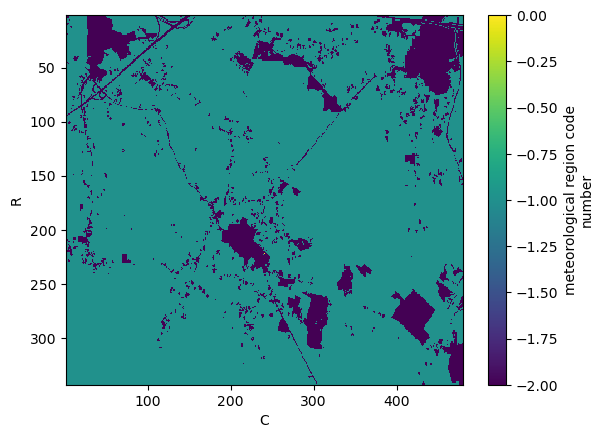

local calibration factor for precipitation


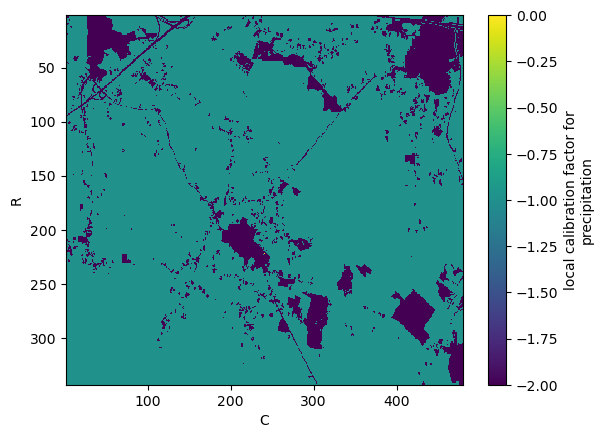

local calibration factor for potential evapotranspiration of reference crop


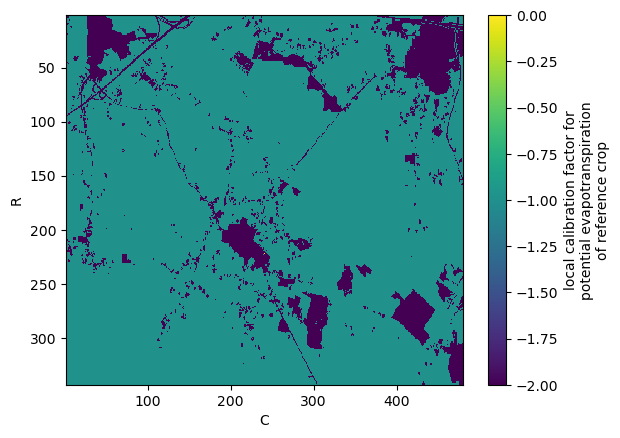

In [48]:
d_missing = {M.MdlN: [], MB.MdlN: []}
for i in range(len(DF_B.columns)-3):
    param = DF_B.columns[3+i]
    print(param)
    if param in DS.data_vars and param in DS_B.data_vars:
        area_RC = DS[param].sum(dim='N', skipna=True)
        area_RC_B = DS_B[param].sum(dim='N', skipna=True)
        area_RC_Diff = area_RC - area_RC_B
        area_RC_Diff.plot(yincrease=False)
        plt.show()
    elif param in DS.data_vars and param not in DS_B.data_vars:
        d_missing[M.MdlN].append(param)
    elif param not in DS.data_vars and param in DS_B.data_vars:
        d_missing[MB.MdlN].append(param)

## 2.2 fact_svat

In [49]:
Fi = 'fact_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

Since DFs are identical, no further investigation is needed.

## 2.4 infi_svat

In [50]:
Fi = 'infi_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [51]:
DF.describe()

,SVAT,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,184024.000000,184024.000000,184024.0,184024.0,184024.0,184024.0
mean,92012.500000,0.932758,9999.0,9999.0,9999.0,1.0
std,53123.297306,0.330695,0.0,0.0,0.0,0.0
min,1.000000,0.000000,9999.0,9999.0,9999.0,1.0
25%,46006.750000,1.050000,9999.0,9999.0,9999.0,1.0
50%,92012.500000,1.050000,9999.0,9999.0,9999.0,1.0
75%,138018.250000,1.050000,9999.0,9999.0,9999.0,1.0
max,184024.000000,1.050000,9999.0,9999.0,9999.0,1.0


In [52]:
DF_B.describe()

,SVAT,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,183388.00000,183388.000000,183388.0,183388.0,183388.0,183388.0
mean,91694.50000,0.932351,-9999.0,-9999.0,-9999.0,-9999.0
std,52939.69992,0.331196,0.0,0.0,0.0,0.0
min,1.00000,0.000000,-9999.0,-9999.0,-9999.0,-9999.0
25%,45847.75000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
50%,91694.50000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
75%,137541.25000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
max,183388.00000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0


#### infiltration capacity of soil surface

In [53]:
param = 'infiltration capacity of soil surface'
param

'infiltration capacity of soil surface'

In [54]:
list(DS.variables.keys())

['SVAT',
 'X',
 'Y',
 'R',
 'C',
 'N',
 'area',
 'soil surface elevation',
 'temperature at bottom of soil profile',
 'soil physical unit number',
 'soil physical unit descriptive string',
 'land use type',
 'root zone thickness / maximum',
 'meteorological region code number',
 'local calibration factor for precipitation',
 'local calibration factor for potential evapotranspiration of reference crop',
 'infiltration capacity of soil surface',
 'downward flow resistance of soil surface',
 'upward flow resistance of soil surface',
 'flow resistance of bottom flux link (c-link)',
 'extra storage coefficient of phreatic layer',
 'maximum abstraction from groundwater mm/d',
 'maximum abstraction from surface water mm/d',
 'maximum abstraction from groundwater m3/d',
 'fraction of abstraction from surface water m3/d',
 'row number of ETREF grid',
 'column number of ETREF grid',
 'row number of PREC grid',
 'column number of PREC grid',
 'surface water location identifier',
 'micro-storage c

In [55]:
area_RC = DS[param].sum(dim='N', skipna=True)
area_RC_B = DS_B[param].sum(dim='N', skipna=True)
area_RC_Diff = area_RC - area_RC_B

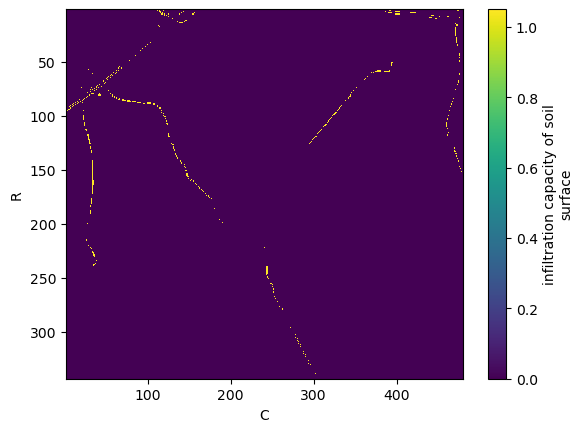

In [56]:
area_RC_Diff.plot(yincrease=False)

This is the same pattern as extra SVATs. The rest of the params are practically NaNs, except "extra storage coefficient of phreatic layer", which also doesn't make a difference (I've tested it).

## 2.5 init_svat

In [57]:
Fi = 'init_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.6 luse_svat

In [58]:
Fi = 'luse_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.7 mete_grid

In [59]:
Fi = 'mete_grid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [60]:
DF.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
DF_B.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['path\name precipitation grid', 'path\name evapotranspiration grid(reference crop values)'], dtype='object')

CAPS diffs in path cols. Those definitely don't matter, otherwise I'd be missing all of P/EVT in one Sim.

## 2.8 mod2svat

In [63]:
Fi = 'mod2svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [64]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['Modflow-id', 'index of SVAT-unit', 'layer of SVAT-unit'], dtype='object')

In [65]:
DF

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
0,1299310,1,13
1,1299311,2,13
2,1299312,3,13
3,1752082,117,17
4,1752083,118,17
...,...,...,...
211462,164635,184020,1
211463,164636,184021,1
211464,164637,184022,1
211465,164638,184023,1


In [66]:
DF.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.114670e+05,211467.000000,211467.000000
mean,2.840734e+05,91266.550871,2.894149
std,5.344250e+05,53119.757743,4.950680
min,4.820000e+02,1.000000,1.000000
25%,4.323250e+04,45523.500000,1.000000
50%,9.399400e+04,90998.000000,1.000000
75%,1.405655e+05,138014.500000,1.000000
max,2.174030e+06,184024.000000,19.000000


In [67]:
DF_B.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.091740e+05,209174.000000,209174.000000
mean,2.743038e+05,91809.175270,2.799927
std,5.237708e+05,53199.856967,4.845565
min,4.820000e+02,1.000000,1.000000
25%,4.299725e+04,46011.250000,1.000000
50%,9.344250e+04,91876.500000,1.000000
75%,1.395698e+05,137687.000000,1.000000
max,2.172913e+06,183388.000000,19.000000


## 2.9 para_sim

In [68]:
Fi = 'para_sim'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

Comments left in .xlsx

Non Array-like, so there is no further exploration.

## 2.10 scap_svat

In [69]:
Fi = 'scap_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [70]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['SVAT', 'maximum abstraction from groundwater mm/d',
       'maximum abstraction from surface water mm/d',
       'maximum abstraction from groundwater m3/d',
       'fraction of abstraction from surface water m3/d'],
      dtype='object')

In [71]:
DF.describe(include='all')

,SVAT,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,25812.000000,0.0,0.0,25812.000000,25812.0
mean,80837.406439,NaN,NaN,15.621422,0.0
std,49697.040372,NaN,NaN,0.008541,0.0
min,1.000000,NaN,NaN,15.518300,0.0
25%,38281.750000,NaN,NaN,15.625000,0.0
50%,81736.500000,NaN,NaN,15.625000,0.0
75%,125832.250000,NaN,NaN,15.625000,0.0
max,163471.000000,NaN,NaN,15.625000,0.0


In [72]:
DF_B.describe(include='all')

,SVAT,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,25786.000000,25786.0,0.0,0.0,0.0
mean,92624.736756,25.0,NaN,NaN,NaN
std,55008.758796,0.0,NaN,NaN,NaN
min,1.000000,25.0,NaN,NaN,NaN
25%,47826.250000,25.0,NaN,NaN,NaN
50%,93258.500000,25.0,NaN,NaN,NaN
75%,141819.750000,25.0,NaN,NaN,NaN
max,183378.000000,25.0,NaN,NaN,NaN


## 2.11 sel_key_svat_per

In [73]:
Fi = 'sel_key_svat_per'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.13 svat2etrefgrid

In [74]:
Fi = 'svat2etrefgrid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [75]:
DF.describe()

,SVAT,row number of ETREF grid,column number of ETREF grid
count,184024.000000,184024.000000,184024.000000
mean,92012.500000,233.503760,119.721254
std,53123.297306,2.530364,3.498742
min,1.000000,229.000000,114.000000
25%,46006.750000,231.000000,117.000000
50%,92012.500000,234.000000,120.000000
75%,138018.250000,236.000000,123.000000
max,184024.000000,238.000000,126.000000


In [76]:
DF_B.describe(include='all')

,SVAT,row number of ETREF grid,column number of ETREF grid
count,183388.00000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816
std,52939.69992,2.530613,3.495910
min,1.00000,229.000000,114.000000
25%,45847.75000,231.000000,117.000000
50%,91694.50000,234.000000,120.000000
75%,137541.25000,236.000000,123.000000
max,183388.00000,238.000000,126.000000


## 2.14 svat2precgrid

In [77]:
Fi = 'svat2precgrid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [78]:
DF.describe()

,SVAT,row number of PREC grid,column number of PREC grid
count,184024.000000,184024.000000,184024.000000
mean,92012.500000,233.503760,119.721254
std,53123.297306,2.530364,3.498742
min,1.000000,229.000000,114.000000
25%,46006.750000,231.000000,117.000000
50%,92012.500000,234.000000,120.000000
75%,138018.250000,236.000000,123.000000
max,184024.000000,238.000000,126.000000


In [79]:
DF_B.describe(include='all')

,SVAT,row number of PREC grid,column number of PREC grid
count,183388.00000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816
std,52939.69992,2.530613,3.495910
min,1.00000,229.000000,114.000000
25%,45847.75000,231.000000,117.000000
50%,91694.50000,234.000000,120.000000
75%,137541.25000,236.000000,123.000000
max,183388.00000,238.000000,126.000000


## 2.15 svat2swnr_roff

In [80]:
Fi = 'svat2swnr_roff'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [81]:
DF.describe()

,SVAT,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance,slope fraction of soil surface for Curve Number Method
count,184024.000000,184024.0,1.840240e+05,184024.0,184024.0,0.0
mean,92012.500000,0.0,2.000000e-03,1.0,1.0,NaN
std,53123.297306,0.0,5.593197e-15,0.0,0.0,NaN
min,1.000000,0.0,2.000000e-03,1.0,1.0,NaN
25%,46006.750000,0.0,2.000000e-03,1.0,1.0,NaN
50%,92012.500000,0.0,2.000000e-03,1.0,1.0,NaN
75%,138018.250000,0.0,2.000000e-03,1.0,1.0,NaN
max,184024.000000,0.0,2.000000e-03,1.0,1.0,NaN


In [82]:
DF_B.describe(include='all')

,SVAT,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance,slope fraction of soil surface for Curve Number Method
count,183388.00000,183388.0,1.833880e+05,183388.0,183388.0,0.0
mean,91694.50000,0.0,2.000000e-03,1.0,1.0,NaN
std,52939.69992,0.0,5.579320e-15,0.0,0.0,NaN
min,1.00000,0.0,2.000000e-03,1.0,1.0,NaN
25%,45847.75000,0.0,2.000000e-03,1.0,1.0,NaN
50%,91694.50000,0.0,2.000000e-03,1.0,1.0,NaN
75%,137541.25000,0.0,2.000000e-03,1.0,1.0,NaN
max,183388.00000,0.0,2.000000e-03,1.0,1.0,NaN


## 2.17 tiop_sim 

In [83]:
Fi = 'tiop_sim'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [84]:
DF.describe()

,time from beginning of year at 00:00:00,year number,option number
count,367.000000,367.000000,367.0
mean,182.002725,1996.002725,7.0
std,106.083313,0.052200,0.0
min,0.000000,1996.000000,7.0
25%,90.500000,1996.000000,7.0
50%,182.000000,1996.000000,7.0
75%,273.500000,1996.000000,7.0
max,365.000000,1997.000000,7.0


In [85]:
DF_B.describe(include='all')

,time from beginning of year at 00:00:00,year number,option number
count,10227.000000,10227.000000,10227.0
mean,182.125257,2006.501027,7.0
std,105.443798,8.078184,0.0
min,0.000000,1993.000000,7.0
25%,91.000000,2000.000000,7.0
50%,182.000000,2007.000000,7.0
75%,273.000000,2013.500000,7.0
max,365.000000,2020.000000,7.0


## 2.18 uscl_svat

Missing in NBr54

# 3 Use NBr52's area in NBr61

In [86]:
# Fi = 'idf_svat'
# DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()

In [87]:
# Fi = 'area_svat'
# DF_area, DF_B_area = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()

In [88]:
# DF_area

In [89]:
# DF_B_area

In [90]:
# DF = DF.merge(DF_area[['SVAT', 'area']], on='SVAT', how='left')
# DF_B = DF_B.merge(DF_B_area[['SVAT', 'area']], on='SVAT', how='left')

In [91]:
# DF

In [92]:
# DF_B

In [93]:
# DF_merge = DF.merge(DF_B, on=['R', 'C', 'N'], how='left', suffixes=('_S', '_B'))

In [94]:
# DF_merge.drop(columns=[i for i in DF_merge.columns if i.startswith('X_') or i.startswith('Y_')] + ['SVAT_B'], inplace=True)

In [95]:
# DF_merge

In [96]:
# DF_area['area'] = DF_merge['area_B'].fillna(DF_merge['area_S'])

In [97]:
# import yaml
# with open(r'g:\code\WS_Mdl\imod\msw\defaults\colspecs.yaml', 'r') as f:
#     colspecs = yaml.safe_load(f)

In [98]:
# DF_area

In [99]:
# import numpy as np

# col_widths = [j[1] - j[0]+1 for j in colspecs['area_svat.inp']][:len(DF_area.columns)]

# fmt_funcs = []
# for i, c in enumerate(DF_area.columns):
#     w = col_widths[i]
#     if pd.api.types.is_float_dtype(DF_area[c]):
#         max_val = DF_area[c].abs().max()
#         pre_dec = int(np.floor(np.log10(max_val))) + 1 if max_val > 0 and not pd.isna(max_val) else 1
#         post_dec = max(0, 5 - pre_dec)
#         fmt_funcs.append(lambda val, w=w, dec=post_dec: f"{val:>{w}.{dec}f}" if not pd.isna(val) else " " * w)
#     else:
#         fmt_funcs.append(lambda val, w=w: f"{val:>{w}}" if not pd.isna(val) else " " * w)

# with open("area_svat_NBr61.inp", "w") as f:
#     for row in DF_area.itertuples(index=False, name=None):
#         formatted_row = "".join(func(val) for func, val in zip(fmt_funcs, row)) + "\n"
#         f.write(formatted_row)

In [100]:
# DF

In [101]:
# DF_area

# 4. Compare MF Ins

NBr63 shows that DRN is most likely the next thing to be fixed, so I'll start with those.

## 4.1 Extra imports

In [171]:
import imod
import numpy as np
import xarray as xra

In [172]:
from importlib import reload as RL
from WS_Mdl.imod.mf6 import nam
from WS_Mdl.imod.mf6 import read
from WS_Mdl.core import mdl
import re

In [173]:
RL(read)
RL(nam)
RL(mdl)

<module 'WS_Mdl.core.mdl' from 'G:\\code\\WS_Mdl\\core\\mdl.py'>

## 4.2 Load imod_python

In [186]:
GRB = imod.mf6.read_grb(M.Pa.GRB) # Load GRB to build DS base

DS = xra.Dataset({k: v for k, v in GRB.items() if isinstance(v, xra.DataArray)})

In [187]:
d_DF = {} # d_ to collect DFs. The rest of the parameters will be added to DS as DataArrays (can be listed with DS.data_vars)

In [188]:
for Pkg in [i for i in M.Pkgs if i not in ['oc', 'dis']][:]: # Loop through model packages. oc is irrelevant for now. dis is already loaded in GRB.
    print(Pkg)
    d_DF[Pkg] = {}

    for Fi in (M.Pa.Sim_In / Pkg).glob('*.dat'):
        Par = Fi.stem
        print(r' '*2, Par, end=' ')

        first_line = Fi.open().readline()

        if '#' in first_line: # If first line starts with '#', the data is contained in DF form.
            first_line = first_line.replace('#', '').strip().split()
            d_DF[Pkg][Par] = pd.read_csv(Fi, sep=r'\s+', names=first_line, skiprows=1)
            print(r' '*4, 'read with pandas')

        else: # Otherwise the data is in array form, so we'll add it to DS.
            A = np.loadtxt(Fi)
            N_L = A.size // M.N_L_cells
            A = A.reshape(M.N_R, M.N_C, ) if N_L == 1 else A.reshape(N_L, M.N_R, M.N_C)
            DS[Par] = xra.DataArray(A, dims=['y', 'x']) if N_L ==1 else xra.DataArray(A, dims=['layer', 'y', 'x'])
            DS[Par].attrs['Pkg'] = Pkg
            print(r' '*4, 'read with numpy')

chd_merged
   chd-0      read with pandas
   chd-1      read with pandas
   chd-10      read with pandas
   chd-11      read with pandas
   chd-12      read with pandas
   chd-2      read with pandas
   chd-3      read with pandas
   chd-4      read with pandas
   chd-5      read with pandas
   chd-6      read with pandas
   chd-7      read with pandas
   chd-8      read with pandas
   chd-9      read with pandas
drn-1
   drn-0      read with pandas
drn-2
   drn-0      read with pandas
drn-3
   drn-0      read with pandas
ic
   strt      read with numpy
msw-rch
   rch      read with pandas
msw-sprinkling
   wel      read with pandas
npf
   icelltype      read with numpy
   k      read with numpy
   k33      read with numpy
riv-1riv
   riv-0      read with pandas
   riv-1      read with pandas
   riv-2      read with pandas
riv-3riv
   riv-0      read with pandas
   riv-1      read with pandas
   riv-2      read with pandas
riv-5riv
   riv-0      read with pandas
   riv-1      read with

In [189]:
pkg_dict = {var_name: da.attrs.get('Pkg') for var_name, da in DS.data_vars.items()}
print(pkg_dict)

{'top': None, 'bottom': None, 'idomain': None, 'icelltype': 'npf', 'strt': 'ic', 'k': 'npf', 'k33': 'npf', 'iconvert': 'sto'}


## 4.3 Compare DRN

#### imod5

In [190]:
from WS_Mdl.imod.mf6.headers import d_Pkg_Cols

In [191]:
d_DRN_5 = {i.name: pd.read_csv(i/'DRN_T1.ARR',
                               names=[col[0] for col in d_Pkg_Cols['DRN']+['aux']],
                               sep=r'\s+',
                               header=None,
                               skipfooter=12,  # Footer contains dimensions
                               engine='python') for i in list((MB.Pa.Sim_In / 'DRN6').iterdir())}

#### Compare

In [192]:
d_DRN_5.keys()

dict_keys(['SYS1', 'SYS2', 'SYS3'])

In [193]:
d_DF.keys()

dict_keys(['chd_merged', 'drn-1', 'drn-2', 'drn-3', 'ic', 'msw-rch', 'msw-sprinkling', 'npf', 'riv-1riv', 'riv-3riv', 'riv-5riv', 'sto', 'wel-WEL_Br_Wa_T_', 'wel-WEL_Ind_Br_T'])

##### 1st system

In [194]:
MB.MdlN

'NBr59'

In [195]:
M.MdlN

'NBr67'

In [196]:
Sys = 1
DA_DRN = d_DF[f'DRN-{Sys}']['drn-0'].rename(columns={'layer': 'k', 'row': 'i', 'column': 'j', 'elevation': 'elev', 'conductance': 'cond'}).set_index(['k', 'i', 'j']).to_xarray()
DA_DRN_5 = d_DRN_5[f'SYS{Sys}'].set_index(['k', 'i', 'j']).to_xarray()

KeyError: 'DRN-1'

In [ ]:
DA_DRN_5

<xarray.Dataset> Size: 4MB
Dimensions:  (k: 1, i: 342, j: 473)
Coordinates:
  * k        (k) int64 8B 1
  * i        (i) int64 3kB 2 3 4 5 6 7 8 9 ... 336 337 338 339 340 341 342 343
  * j        (j) int64 4kB 2 3 4 5 6 7 8 9 ... 472 473 474 475 476 477 478 479
Data variables:
    elev     (k, i, j) float64 1MB 3.255 3.212 3.225 3.203 ... nan nan nan nan
    cond     (k, i, j) float64 1MB 18.94 18.94 18.94 18.94 ... nan nan nan nan
    a        (k, i, j) float64 1MB 1.0 1.0 1.0 1.0 nan ... nan nan nan nan nan

In [ ]:
float((DA_DRN['elev'] - DA_DRN_5['elev']).min().values), float((DA_DRN['elev'] - DA_DRN_5['elev']).max().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).min().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).max().values)

(-0.0005048904418956113,
 0.000504997253418793,
 -0.00018265533447525684,
 0.00039399719238275566)

##### 2nd system

In [ ]:
Sys = 2
DA_DRN = d_DF[f'DRN-{Sys}']['drn-0'].rename(columns={'layer': 'k', 'row': 'i', 'column': 'j', 'elevation': 'elev', 'conductance': 'cond'}).set_index(['k', 'i', 'j']).to_xarray()
DA_DRN_5 = d_DRN_5[f'SYS{Sys}'].set_index(['k', 'i', 'j']).to_xarray()

In [ ]:
float((DA_DRN['elev'] - DA_DRN_5['elev']).min().values), float((DA_DRN['elev'] - DA_DRN_5['elev']).max().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).min().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).max().values)  

(-0.0005049743652367766,
 0.0005049438476554258,
 0.0003282470703140916,
 0.0003282470703140916)

##### 3rd system

In [ ]:
Sys = 3
DA_DRN = d_DF[f'DRN-{Sys}']['drn-0'].rename(columns={'layer': 'k', 'row': 'i', 'column': 'j', 'elevation': 'elev', 'conductance': 'cond'}).set_index(['k', 'i', 'j']).to_xarray()
DA_DRN_5 = d_DRN_5[f'SYS{Sys}'].set_index(['k', 'i', 'j']).to_xarray()

In [ ]:
float((DA_DRN['elev'] - DA_DRN_5['elev']).min().values), float((DA_DRN['elev'] - DA_DRN_5['elev']).max().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).min().values), float((DA_DRN['cond'] - DA_DRN_5['cond']).max().values)

(-0.0005004348754891197,
 0.0005049896240230112,
 -6.982421875179057e-05,
 0.00040018463134761095)

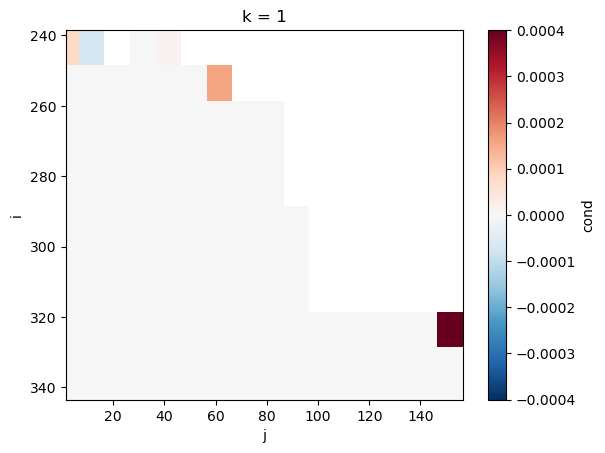

In [ ]:
(DA_DRN['cond'] - DA_DRN_5['cond']).plot(yincrease=False)

In [ ]:
d_DF[f'DRN-{Sys}']['drn-0']

,layer,row,column,elevation,conductance
0,1,239,2,3.724010,20.71408
1,1,239,3,3.752008,20.71408
2,1,239,4,3.780008,20.71408
3,1,239,5,3.808007,20.71408
4,1,239,6,3.836005,20.71408
...,...,...,...,...,...
10270,1,343,152,11.797400,6.25000
10271,1,343,153,11.797400,6.25000
10272,1,343,154,11.797400,6.25000
10273,1,343,155,11.797400,6.25000


In [ ]:
d_DRN_5[f'SYS1']

,k,i,j,elev,cond,a
0,1,2,2,3.255,18.939,1
1,1,2,3,3.212,18.939,1
2,1,2,4,3.225,18.939,1
3,1,2,5,3.203,18.939,1
4,1,2,143,5.777,8.803,1
...,...,...,...,...,...,...
22485,1,343,352,19.009,8.803,1
22486,1,343,353,18.734,8.803,1
22487,1,343,354,18.738,8.803,1
22488,1,343,355,18.846,8.803,1


Drainage differences are tiny (rounding) for most systems, except for the 3rd system's conductance (Belgium) - the values in imod_python are 100* larger. I'll investigate further. First hunch is that the conductance values are very big in this system.

#### Figure out why this went wrong

In [ ]:
d_DF[f'DRN-1']['drn-0'].describe()

,layer,row,column,elevation,conductance
count,22490.0,22490.000000,22490.000000,22490.000000,22490.000000
mean,1.0,170.686661,267.534104,12.102839,9.431010
std,0.0,106.548806,112.202418,4.090365,2.445297
min,1.0,2.000000,2.000000,0.784285,7.911392
25%,1.0,68.000000,187.000000,9.242107,8.802817
50%,1.0,174.000000,267.000000,11.903773,8.802817
75%,1.0,274.000000,356.000000,15.153003,8.802817
max,1.0,343.000000,479.000000,23.819979,18.939394


In [ ]:
d_DF[f'DRN-2']['drn-0'].describe()

,layer,row,column,elevation,conductance
count,163476.0,163476.000000,163476.000000,163476.000000,163476.000000
mean,1.0,172.500000,240.500000,12.799103,208.333328
std,0.0,98.726776,137.986834,5.218773,0.000000
min,1.0,2.000000,2.000000,1.083936,208.333328
25%,1.0,87.000000,121.000000,8.804660,208.333328
50%,1.0,172.500000,240.500000,12.220000,208.333328
75%,1.0,258.000000,360.000000,16.572190,208.333328
max,1.0,343.000000,479.000000,29.856264,208.333328


In [ ]:
d_DF[f'DRN-3']['drn-0'].describe()

,layer,row,column,elevation,conductance
count,10275.0,10275.000000,10275.000000,10275.000000,10275.000000
mean,1.0,301.218978,57.296837,9.212202,6.684331
std,0.0,29.051764,38.127968,1.729672,2.674924
min,1.0,239.000000,2.000000,3.724010,0.591400
25%,1.0,277.000000,27.000000,8.057966,6.250000
50%,1.0,305.000000,52.000000,9.720375,6.250000
75%,1.0,327.000000,80.000000,10.371816,6.250000
max,1.0,343.000000,156.000000,12.690259,20.714080


In [ ]:
d_DRN_5[f'SYS1'].describe()

,k,i,j,elev,cond,a
count,22490.0,22490.000000,22490.000000,22490.000000,22490.000000,22490.0
mean,1.0,170.686661,267.534104,12.102839,9.431156,1.0
std,0.0,106.548806,112.202418,4.090368,2.445158,0.0
min,1.0,2.000000,2.000000,0.784000,7.911000,1.0
25%,1.0,68.000000,187.000000,9.242250,8.803000,1.0
50%,1.0,174.000000,267.000000,11.903500,8.803000,1.0
75%,1.0,274.000000,356.000000,15.153000,8.803000,1.0
max,1.0,343.000000,479.000000,23.820000,18.939000,1.0


In [ ]:
d_DRN_5[f'SYS2'].describe()

,k,i,j,elev,cond,a
count,163476.0,163476.000000,163476.000000,163476.000000,1.634760e+05,163476.0
mean,1.0,172.500000,240.500000,12.799103,2.083330e+02,2.0
std,0.0,98.726776,137.986834,5.218773,3.357751e-10,0.0
min,1.0,2.000000,2.000000,1.084000,2.083330e+02,2.0
25%,1.0,87.000000,121.000000,8.804750,2.083330e+02,2.0
50%,1.0,172.500000,240.500000,12.220000,2.083330e+02,2.0
75%,1.0,258.000000,360.000000,16.572000,2.083330e+02,2.0
max,1.0,343.000000,479.000000,29.856000,2.083330e+02,2.0


In [ ]:
d_DRN_5[f'SYS3'].describe()

,k,i,j,elev,cond,a
count,10275.0,10275.000000,10275.000000,10275.000000,10275.000000,10275.0
mean,1.0,301.218978,57.296837,9.212214,6.684326,3.0
std,0.0,29.051764,38.127968,1.729655,2.674926,0.0
min,1.0,239.000000,2.000000,3.724000,0.591000,3.0
25%,1.0,277.000000,27.000000,8.058000,6.250000,3.0
50%,1.0,305.000000,52.000000,9.720000,6.250000,3.0
75%,1.0,327.000000,80.000000,10.372000,6.250000,3.0
max,1.0,343.000000,156.000000,12.690000,20.714000,3.0


## 4.4 Compare CHD

In [198]:
d_DF['chd_merged'].keys()

dict_keys(['chd-0', 'chd-1', 'chd-10', 'chd-11', 'chd-12', 'chd-2', 'chd-3', 'chd-4', 'chd-5', 'chd-6', 'chd-7', 'chd-8', 'chd-9'])

In [200]:
DF_CHD = d_DF['chd_merged']['chd-0'].rename(columns={'layer': 'k', 'row': 'i', 'column': 'j', 'elevation': 'elev'})
A_CHD = DF_CHD.set_index(['k', 'i', 'j'])['head'].to_xarray()

In [229]:
d_CHD_5 = {i.parent.name: pd.read_csv(i,
                               names=[col[0] for col in d_Pkg_Cols['CHD']]+['aux1', 'aux2'],
                               sep=r'\s+',
                               skipfooter=12,  # Footer contains dimensions
                               engine='python') for i in list((MB.Pa.Sim_In / 'CHD6').rglob('*CHD_T1.ARR'))}
DF_CHD_5 = pd.concat([i for i in d_CHD_5.values() if not i.empty], ignore_index=True).drop(columns=['aux1', 'aux2'])
A_CHD_5 = DF_CHD_5.set_index(['k', 'i', 'j'])['head'].to_xarray()

### Save to TIF to compare in QGIS

In [232]:
DF_CHD_5 = DF_CHD_5.ws.Calc_XY(MB.Xmin, MB.Ymax, MB.cellsize)
A_CHD_5_XY = DF_CHD_5.set_index(['k', 'y', 'x'])['head'].to_xarray()

In [ ]:
A_CHD_5_XY.rio.to_raster('CHD_5.tif')

SyntaxError: invalid syntax (2643741264.py, line 1)

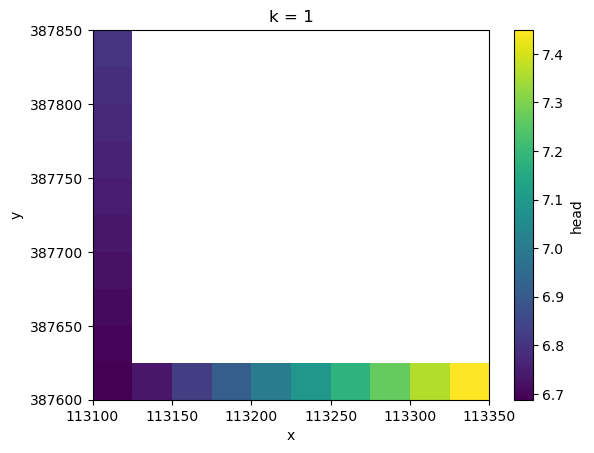

In [234]:
A_CHD_5_XY.sel(k=1).isel(x=slice(0,10), y=slice(0,10)).plot()

### L1

In [203]:
A_CHD_Diff = A_CHD - A_CHD_5

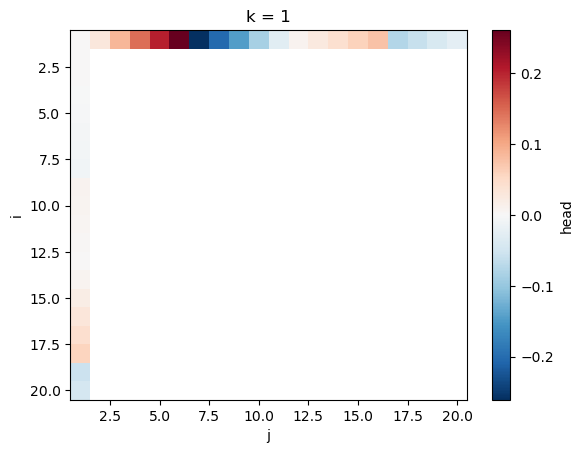

In [204]:
(A_CHD_Diff).sel(k=1, i=slice(0, 20), j=slice(0, 20)).plot(yincrease=False)

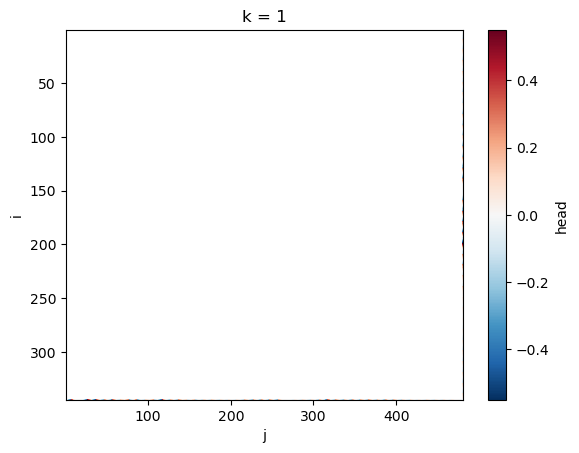

In [239]:
(A_CHD_Diff).sel(k=1).plot(yincrease=False) 

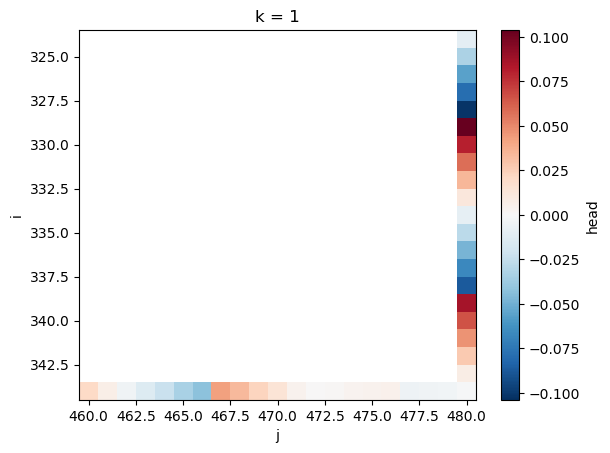

In [241]:
(A_CHD_Diff).sel(k=1, i=slice(324, 344), j=slice(460, 480)).plot(yincrease=False)

# -1 Junkyard

In [ ]:
# Pa = MB.Pa.Sim_In / r'DRN6/SYS3\DRN_T1.ARR'

In [ ]:
# DF = pd.read_csv(Pa, names=[col[0] for col in d_Pkg_Cols['DRN']], sep=r'\s+', header=None, skipfooter=12, engine='python')
# DF['cond'] = DF['cond'] * 100
# footer = open(Pa).readlines()[-12:]

In [ ]:
# DF

In [ ]:
# with open(Pa, 'w') as f:
#     f.writelines(DF.ws.to_MF_block())
#     f.writelines(footer)

In [ ]:
# Pa = MB.Pa.Sim_In / r'DRN6/SYS3\DRN_T1.ARR'
# DF = pd.read_csv(Pa, names=[col[0] for col in d_Pkg_Cols['DRN']], sep=r'\s+', header=None, skipfooter=12, engine='python')
# DF['cond'] = DF['cond'] * 100
# footer = open(Pa).readlines()[-12:]
# with open(Pa, 'w') as f:
#     f.writelines(DF.ws.to_MF_block())
#     f.writelines(footer)

In [ ]:
stop

In [ ]:
d_MF6_In = {p.name : {'DF': None, 'DS'} for p in M.Pa.Sim_In.iterdir() if p.is_dir()}

In [ ]:
import flopy as fp

In [ ]:
Sim = fp.mf6.MFSimulation.load(sim_ws=M.Pa.MdlN, verbosity_level=1)

In [ ]:
with open(M.Pa.NAM_Mdl, 'r', encoding='utf-8') as f:
    text = f.read()

d_blocks = {}
for m in re.finditer(
    r'(?ims)^\s*BEGIN\s+([^\s#;!]+)\b[^\n]*\n(.*?)^\s*END\b[^\n]*$',
    text,
 ):
    d_blocks[m.group(1).lower()] = m.group(2)

In [ ]:
d_blocks

In [ ]:
def MF6_In_to_d(Pa):
    """
    Created dictionary from MF6 input file, where the key is the name of the block and the value is a DF of the block's data.
    """
    d = {}
    block = None
    lines = []

    for line in Path(Pa).read_text(encoding='utf-8').splitlines():
        s = line.strip()

        if not s or s.startswith(('#', '!')):
            continue

        parts = s.split()
        key = parts[0].upper()

        if key == 'BEGIN':
            block = parts[1].lower()
            lines = []
            continue

        if key == 'END':
            d.setdefault(block, []).append(lines.copy())
            block = None
            lines = []
            continue

        if block is not None:
            lines.append(s)

    return d

In [ ]:
NAM

In [ ]:
for k in MB.MSW_In.d.keys():
    try:
        print('\n'.join(MB.MSW_In.d[k].columns))
        print('---------------------')
    except:
        continue